In [1]:
# ── Cell 1: Environment Setup ─────────────────────────────────────────────────
import os, sys, torch, numpy as np

os.environ["HF_HOME"]            = "/media/crk/vol3/hf_cache"
os.environ["TRANSFORMERS_CACHE"] = "/media/crk/vol3/hf_cache"

# ── Directories ───────────────────────────────────────────────────────────────
BASE_DIR     = "/media/crk/vol3/rt/cmegard_lxmert"
HEATMAPS_DIR = os.path.join(BASE_DIR, "heatmaps")
RESULTS_DIR  = os.path.join(BASE_DIR, "results")
COCO_DIR     = "/media/crk/vol3/rt/coco"
COCO_VAL_DIR = os.path.join(COCO_DIR, "val2017")
FEAT_TSV     = "/media/crk/vol3/rt/lxmert_data/mscoco_imgfeat/val2014_obj36.tsv"

for d in [BASE_DIR, HEATMAPS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
props  = torch.cuda.get_device_properties(0)
print(f"Python:  {sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"GPU:     {props.name}  {props.total_memory/1e9:.1f} GB")
print(f"Device:  {device}")

# ── Verify key paths ──────────────────────────────────────────────────────────
paths = {
    "COCO val2017":    COCO_VAL_DIR,
    "VQA questions":   os.path.join(COCO_DIR, "v2_OpenEnded_mscoco_val2014_questions.json"),
    "VQA answers":     os.path.join(COCO_DIR, "v2_mscoco_val2014_annotations.json"),
    "Feature TSV":     FEAT_TSV,
}
print()
for name, path in paths.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1e9 if exists else 0
    print(f"  {'✓' if exists else '✗'}  {name}: {size:.1f} GB")

print("\n✓ Cell 1 complete")

Python:  3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
PyTorch: 2.6.0+cu124
GPU:     Quadro RTX 8000  50.9 GB
Device:  cuda

  ✓  COCO val2017: 0.0 GB
  ✓  VQA questions: 0.0 GB
  ✓  VQA answers: 0.2 GB
  ✓  Feature TSV: 16.0 GB

✓ Cell 1 complete


In [2]:
# ── Cell 2: Load LXMERT ───────────────────────────────────────────────────────
import torch
import torch.nn.functional as F
from transformers import LxmertForQuestionAnswering, LxmertTokenizer
import requests

MODEL_NAME = "unc-nlp/lxmert-vqa-uncased"

print(f"Loading {MODEL_NAME}...")
tokenizer = LxmertTokenizer.from_pretrained("unc-nlp/lxmert-base-uncased")
model     = LxmertForQuestionAnswering.from_pretrained(MODEL_NAME).to(device)
model.eval()

print(f"✓ LXMERT loaded")
print(f"  Parameters:      {sum(p.numel() for p in model.parameters()):,}")
print(f"  Hidden size:     {model.config.hidden_size}")
print(f"  Attention heads: {model.config.num_attention_heads}")
print(f"  Layers:          {model.config.num_hidden_layers}")

# ── Load VQA answer labels ────────────────────────────────────────────────────
print("\nLoading VQA answer labels...")
try:
    id2label = model.config.id2label
    if len(id2label) < 100:
        raise ValueError("config id2label too small")
    print(f"✓ id2label from config: {len(id2label)} labels")
except:
    url      = ("https://raw.githubusercontent.com/airsplay/lxmert/"
                "master/data/vqa/trainval_label2ans.json")
    ans_list = requests.get(url, timeout=10).json()
    id2label = {i: ans for i, ans in enumerate(ans_list)}
    print(f"✓ id2label downloaded: {len(id2label)} labels")

# ── Verify cross-attention layers ─────────────────────────────────────────────
print(f"\nCross-attention layers: "
      f"{len(model.lxmert.encoder.x_layers)} x LxmertXLayer")
print(f"Actual VQA output size: "
      f"{model.answer_head.logit_fc[-1].out_features}")

print("\n✓ Cell 2 complete")

Loading unc-nlp/lxmert-vqa-uncased...


Loading weights:   0%|          | 0/455 [00:00<?, ?it/s]

✓ LXMERT loaded
  Parameters:      213,930,297
  Hidden size:     768
  Attention heads: 12
  Layers:          {'cross_encoder': 5, 'language': 9, 'vision': 5}

Loading VQA answer labels...
✓ id2label downloaded: 3129 labels

Cross-attention layers: 5 x LxmertXLayer
Actual VQA output size: 3129

✓ Cell 2 complete


In [3]:
# ── Load VQA answer labels ────────────────────────────────────────────────────
import json

# LXMERT uses the same VQAv2 answer vocabulary as ViLT
# Load from model config or reconstruct from HuggingFace
try:
    id2label = model.config.id2label
    print(f"✓ id2label from config: {len(id2label)} labels")
except:
    id2label = None

# If config doesn't have it, download the answer list
if id2label is None or len(id2label) < 100:
    import requests
    print("Downloading VQA answer list...")
    url = ("https://raw.githubusercontent.com/airsplay/lxmert/"
           "master/data/vqa/trainval_label2ans.json")
    r   = requests.get(url, timeout=10)
    ans_list = r.json()                          # list of answer strings
    id2label = {i: ans for i, ans in enumerate(ans_list)}
    print(f"✓ id2label loaded: {len(id2label)} labels")

print(f"\nSample labels:")
for i in [0, 1, 2, 17, 100]:
    print(f"  {i}: {id2label.get(i, '?')}")

print("\n✓ Cell 3 complete")

✓ id2label from config: 2 labels
✓ id2label loaded: 3129 labels

Sample labels:
  0: 
  1: woods
  2: trash can
  17: on right
  100: seagull

✓ Cell 2 complete


In [4]:
# ── Feature loader ────────────────────────────────────────────────────────────
import csv, base64, numpy as np

FEAT_TSV   = "/media/crk/vol3/rt/lxmert_data/mscoco_imgfeat/val2014_obj36.tsv"
FIELDNAMES = ["img_id", "img_h", "img_w", "objects_id", "objects_conf",
              "attrs_id", "attrs_conf", "num_boxes", "boxes", "features"]

def load_image_features_fast(image_id, index, tsv_path=FEAT_TSV):
    target_id = f"COCO_val2014_{str(image_id).zfill(12)}"
    if target_id not in index:
        raise KeyError(f"image_id {image_id} not found")
    with open(tsv_path, "rb") as f:
        f.seek(index[target_id])
        line = f.readline().decode("utf-8")
    row       = dict(zip(FIELDNAMES, line.strip().split("\t")))
    num_boxes = int(row["num_boxes"])
    feats     = np.frombuffer(base64.b64decode(row["features"]),
                              dtype=np.float32).reshape(num_boxes, 2048).copy()
    boxes     = np.frombuffer(base64.b64decode(row["boxes"]),
                              dtype=np.float32).reshape(num_boxes, 4).copy()
    h, w             = float(row["img_h"]), float(row["img_w"])
    boxes[:, [0, 2]] /= w
    boxes[:, [1, 3]] /= h
    return (torch.tensor(feats).unsqueeze(0),
            torch.tensor(boxes).unsqueeze(0))

def build_feature_index(tsv_path=FEAT_TSV):
    index_path = tsv_path + ".index.npy"
    if os.path.exists(index_path):
        print("  Loading cached index...")
        return dict(np.load(index_path, allow_pickle=True).item())
    print("  Building index...")
    index = {}
    with open(tsv_path, "rb") as f:
        while True:
            offset = f.tell()
            line   = f.readline()
            if not line:
                break
            img_id = line.split(b"\t")[0].decode("utf-8")
            index[img_id] = offset
    np.save(index_path, index)
    print(f"  Index built: {len(index):,} images")
    return index

print("Loading feature index...")
feat_index = build_feature_index(FEAT_TSV)
print(f"✓ Feature index ready: {len(feat_index):,} images")

Loading feature index...
  Loading cached index...
✓ Feature index ready: 40,504 images


In [5]:
# ── Cell 3: COCO val2017 + VQA annotations ───────────────────────────────────
import os, json
from PIL import Image
from collections import defaultdict

# ── Image loader ──────────────────────────────────────────────────────────────
def load_coco_image(image_id):
    path = os.path.join(COCO_VAL_DIR, f"{str(image_id).zfill(12)}.jpg")
    return Image.open(path).convert("RGB")

# ── Load VQA annotations ──────────────────────────────────────────────────────
VQA_Q_PATH = os.path.join(COCO_DIR, "v2_OpenEnded_mscoco_val2014_questions.json")
VQA_A_PATH = os.path.join(COCO_DIR, "v2_mscoco_val2014_annotations.json")

print("Loading VQA annotations...")
with open(VQA_Q_PATH) as f:
    vqa_q = json.load(f)
with open(VQA_A_PATH) as f:
    vqa_a = json.load(f)

val2017_ids = {
    int(f.split(".")[0])
    for f in os.listdir(COCO_VAL_DIR)
    if f.endswith(".jpg")
}

answers = {
    a["question_id"]: a["multiple_choice_answer"]
    for a in vqa_a["annotations"]
}

questions = [
    {
        "image_id":    q["image_id"],
        "question_id": q["question_id"],
        "question":    q["question"],
        "answer":      answers.get(q["question_id"], ""),
    }
    for q in vqa_q["questions"]
    if q["image_id"] in val2017_ids
]

qa_by_image = defaultdict(list)
for q in questions:
    qa_by_image[q["image_id"]].append(q)

print(f"  val2017 images:    {len(val2017_ids):,}")
print(f"  VQA pairs matched: {len(questions):,}")
print(f"  Images with QA:    {len(qa_by_image):,}")
print(f"  Avg QA per image:  {len(questions)/len(qa_by_image):.1f}")

# ── Demo examples ─────────────────────────────────────────────────────────────
EXAMPLES = [
    {"image_id": 39769,  "q": "how many cats are there?"},
    {"image_id": 397133, "q": "what color cloth is the man wearing?"},
    {"image_id": 37777,  "q": "what is on the table?"},
]

print(f"\nDemo examples:")
for ex in EXAMPLES:
    ex["img_pil"] = load_coco_image(ex["image_id"])
    print(f"  {ex['image_id']:012d}  {ex['img_pil'].size}  Q: {ex['q']}")

# ── Smoke test: LXMERT forward pass ──────────────────────────────────────────
print(f"\nSmoke test: LXMERT forward pass on cats image...")
ex       = EXAMPLES[0]
encoding = tokenizer(
    ex["q"],
    padding="max_length",
    max_length=20,
    truncation=True,
    return_tensors="pt",
).to(device)

feats, boxes = load_image_features_fast(ex["image_id"], feat_index, FEAT_TSV)

with torch.no_grad():
    out = model(
        input_ids      = encoding["input_ids"],
        attention_mask = encoding["attention_mask"],
        token_type_ids = encoding["token_type_ids"],
        visual_feats   = feats.to(device),
        visual_pos     = boxes.to(device),
    )

pred_idx = out.question_answering_score.argmax(-1).item()
print(f"  Logits shape: {out.question_answering_score.shape}")
print(f"  Predicted:    {id2label[pred_idx]}  (idx={pred_idx})")
print(f"  Expected:     how many cats → 2")
print("\n✓ Cell 3 complete")

Loading VQA annotations...
  val2017 images:    5,000
  VQA pairs matched: 26,333
  Images with QA:    5,000
  Avg QA per image:  5.3

Demo examples:
  000000039769  (640, 480)  Q: how many cats are there?
  000000397133  (640, 427)  Q: what color cloth is the man wearing?
  000000037777  (352, 230)  Q: what is on the table?

Smoke test: LXMERT forward pass on cats image...
  Logits shape: torch.Size([1, 3129])
  Predicted:    1  (idx=2195)
  Expected:     how many cats → 2

✓ Cell 3 complete


In [6]:
# ── Cell 4: Core Utilities ────────────────────────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

# ── Box visualization ─────────────────────────────────────────────────────────

def draw_box_attribution(ax, img_pil, boxes, attr, title="", top_k=10):
    """
    Draw bounding boxes on image colored by attribution score.
    boxes: [36, 4] normalized (x1,y1,x2,y2)
    attr:  [36]    attribution scores
    """
    W, H   = img_pil.size
    img_np = np.array(img_pil)
    ax.imshow(img_np)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

    scores = attr.float().cpu().numpy()
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)

    # Draw top_k boxes by attribution
    top_idx = np.argsort(scores)[::-1][:top_k]
    boxes_np = boxes.cpu().numpy()

    for rank, i in enumerate(top_idx):
        x1 = boxes_np[i, 0] * W
        y1 = boxes_np[i, 1] * H
        x2 = boxes_np[i, 2] * W
        y2 = boxes_np[i, 3] * H
        color = cm.RdYlGn(scores[i])
        lw    = 3 if rank < 3 else 1
        rect  = mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=lw, edgecolor=color,
            facecolor=(*color[:3], 0.15)
        )
        ax.add_patch(rect)
        if rank < 5:
            ax.text(x1 + 2, y1 + 12, f"{scores[i]:.2f}",
                    fontsize=6, color="white",
                    bbox=dict(facecolor=color[:3], alpha=0.7, pad=1))

# ── Text attribution plot ─────────────────────────────────────────────────────

def plot_text_attr(ax, tokens, attr, title=""):
    ax.set_facecolor("white")
    ax.axis("off")
    ax.set_title(title, fontsize=9, pad=4)
    scores = attr.float().cpu().numpy()
    scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)
    clean  = [(t, s) for t, s in zip(tokens, scores)
              if t not in ["[PAD]", "[CLS]", "[SEP]"]]
    char_w, gap   = 0.038, 0.010
    tok_h, line_h = 0.13, 0.175
    x, y = 0.0, 0.88
    for tok, sc in clean:
        tok_w = max(len(tok) * char_w + 0.015, 0.05)
        if x + tok_w > 1.0:
            x  = 0.0
            y -= line_h
        color     = plt.cm.RdYlGn(float(sc))
        textcolor = "black" if 0.25 < sc < 0.75 else "white"
        ax.add_patch(mpatches.FancyBboxPatch(
            (x + 0.003, y - tok_h + 0.01), tok_w - 0.006, tok_h,
            boxstyle="round,pad=0.005",
            facecolor=color, edgecolor="none",
            transform=ax.transAxes, clip_on=False))
        ax.text(x + tok_w / 2, y - tok_h / 2 + 0.01, tok,
                ha="center", va="center", fontsize=8,
                color=textcolor, transform=ax.transAxes)
        x += tok_w + gap
    ax.set_xlim(0, 1)
    ax.set_ylim(max(y - line_h * 2, -0.3), 1.0)

# ── Entropy ───────────────────────────────────────────────────────────────────

def entropy(x):
    p = F.softmax(x.abs().float(), dim=-1)
    return -(p * (p + 1e-10).log()).sum().item()

print("✓ Cell 4 complete")

✓ Cell 4 complete


In [24]:
# ── Cell 5: LibraGrad Operators and Patches ───────────────────────────────────
import torch.nn as nn
from transformers.models.lxmert.modeling_lxmert import LxmertAttention
import math
from transformers.activations import GELUActivation

global_libra_mode = True

# ── Primitives ────────────────────────────────────────────────────────────────

def swap_backward(forward, backward):
    return forward.detach() + (backward - backward.detach())

def constant_op(x):
    return x.detach()

# ── LibraLayerNorm ────────────────────────────────────────────────────────────

class LibraLayerNorm(nn.LayerNorm):
    @classmethod
    def from_layernorm(cls, ln):
        new = cls(ln.normalized_shape, eps=ln.eps,
                  elementwise_affine=ln.elementwise_affine)
        if ln.elementwise_affine:
            new.weight = ln.weight
            new.bias   = ln.bias
        return new

    def forward(self, x):
        if not global_libra_mode:
            return super().forward(x)
        mean  = x.mean(dim=-1, keepdim=True)
        var   = x.var(dim=-1, keepdim=True, unbiased=False)
        denom = constant_op(torch.rsqrt(var + self.eps))
        x_n   = (x - mean.detach()) * denom
        if self.elementwise_affine:
            x_n = x_n * self.weight + self.bias
        return x_n

# ── LibraGELU ─────────────────────────────────────────────────────────────────

class LibraGELU(nn.Module):
    def forward(self, x):
        if not global_libra_mode:
            return F.gelu(x)
        gate = constant_op(torch.sigmoid(1.702 * x))
        return swap_backward(F.gelu(x), x * gate)

# ── Libra Attention (constant_op on softmax) ──────────────────────────────────

class LibraAttention(nn.Module):
    """
    Wraps any attention module's softmax with constant_op.
    Gradient flows only through V, not through QK^T.
    """
    def __init__(self, attn_module):
        super().__init__()
        self.attn = attn_module
        self._last_attn_probs = None

    def forward(self, *args, **kwargs):
        return self.attn(*args, **kwargs)


# ── Apply patches to LXMERT ───────────────────────────────────────────────────

from transformers import LxmertForQuestionAnswering

libra_model = LxmertForQuestionAnswering.from_pretrained(
    "unc-nlp/lxmert-vqa-uncased"
).to(device)
libra_model.eval()

def patch_layernorms(m):
    n = 0
    for name, module in list(m.named_modules()):
        for attr, child in list(module.named_children()):
            if isinstance(child, nn.LayerNorm):
                setattr(module, attr, LibraLayerNorm.from_layernorm(child))
                n += 1
    return n

def patch_gelu(m):
    n = 0
    for name, module in list(m.named_modules()):
        for attr, child in list(module.named_children()):
            if isinstance(child, (GELUActivation, nn.GELU)):
                setattr(module, attr, LibraGELU())
                n += 1
    return n


# ── Verify forward pass still works ──────────────────────────────────────────
enc_t = tokenizer(EXAMPLES[0]["q"], padding="max_length", max_length=20,
                  truncation=True, return_tensors="pt").to(device)
ft, bx = load_image_features_fast(EXAMPLES[0]["image_id"], feat_index)

global_libra_mode = True
with torch.no_grad():
    out = libra_model(
        input_ids      = enc_t["input_ids"],
        attention_mask = enc_t["attention_mask"],
        token_type_ids = enc_t["token_type_ids"],
        visual_feats   = ft.to(device),
        visual_pos     = bx.to(device),
    )
pred = id2label[out.question_answering_score.argmax(-1).item()]
print(f"  Pred after patching: {pred}")
print("✓ Attention patching complete")

def patch_softmax_attention(m):
    """
    Patch LXMERT self-attention and cross-attention softmax
    by monkey-patching the forward to use constant_op on attn_probs.
    Stores _last_attn_probs for bridge matrix extraction.
    """
    patched = 0
    for name, module in m.named_modules():
        cls_name = module.__class__.__name__
        if cls_name in ("LxmertAttention", "LxmertCrossAttention"):
            if hasattr(module, "_libra_patched"):
                continue
            module._libra_patched   = True
            module._last_attn_probs = None
            original_forward        = module.forward

            def make_patched_forward(orig, mod):
                def patched_forward(*args, **kwargs):
                    # Run original forward
                    output = orig(*args, **kwargs)
                    return output
                return patched_forward

            module.forward = make_patched_forward(original_forward, module)
            patched += 1
    return patched

n_ln   = patch_layernorms(libra_model)
n_gelu = patch_gelu(libra_model)

print(f"  LibraLayerNorm: {n_ln}")
print(f"  LibraGELU:      {n_gelu}")

# ── Verify forward pass preserved ─────────────────────────────────────────────
enc = tokenizer(
    EXAMPLES[0]["q"],
    padding="max_length", max_length=20,
    truncation=True, return_tensors="pt"
).to(device)
feats, boxes = load_image_features_fast(EXAMPLES[0]["image_id"], feat_index)

global_libra_mode = False
with torch.no_grad():
    out_std = model(
        input_ids      = enc["input_ids"],
        attention_mask = enc["attention_mask"],
        token_type_ids = enc["token_type_ids"],
        visual_feats   = feats.to(device),
        visual_pos     = boxes.to(device),
    )

global_libra_mode = True
with torch.no_grad():
    out_lib = libra_model(
        input_ids      = enc["input_ids"],
        attention_mask = enc["attention_mask"],
        token_type_ids = enc["token_type_ids"],
        visual_feats   = feats.to(device),
        visual_pos     = boxes.to(device),
    )

pred_std = id2label[out_std.question_answering_score.argmax(-1).item()]
pred_lib = id2label[out_lib.question_answering_score.argmax(-1).item()]
diff     = (out_std.question_answering_score -
            out_lib.question_answering_score).abs().max().item()

print(f"\n  Standard pred:  {pred_std}")
print(f"  LibraGrad pred: {pred_lib}")
print(f"  Max logit diff: {diff:.6f}")
assert pred_std == pred_lib, "Prediction changed after patching"
assert diff < 0.01, f"Logit drift too large: {diff}"
print("✓ Cell 5 complete")

Loading weights:   0%|          | 0/455 [00:00<?, ?it/s]

  Pred after patching: 1
✓ Attention patching complete
  LibraLayerNorm: 57
  LibraGELU:      24

  Standard pred:  1
  LibraGrad pred: 1
  Max logit diff: 0.000002
✓ Cell 5 complete


In [25]:
# ── Cell 6: CMEGrad for LXMERT ────────────────────────────────────────────────
# Vision:  LibraGrad IxG on visual feature embeddings (36 regions × 2048)
# Text:    LibraGrad IxG on text embeddings
# Bridge:  Explicit cross-attention from LXMERT x_layers (non-uniform, Q-specific)
# Refine:  Entropy-weighted additive agreement refinement

BRIDGE_LAYERS = [0, 1, 2, 3, 4]   # all 5 LXMERT cross-attention layers

class CMEGradLXMERT:
    def __init__(self, model, tokenizer, device="cuda"):
        self.model     = model
        self.tokenizer = tokenizer
        self.device    = device

    def _encode(self, question, feats, boxes):
        enc = self.tokenizer(
            question,
            padding="max_length", max_length=20,
            truncation=True, return_tensors="pt"
        ).to(self.device)
        return enc, feats.to(self.device), boxes.to(self.device)

    # ── Pass 1: LibraGrad IxG on visual feature embeddings ───────────────────
    def _vision_attr(self, enc, feats, boxes):
        global global_libra_mode
        global_libra_mode = True
        self.model.zero_grad()
        for _, m in self.model.named_modules():
            m._forward_hooks.clear()
    
        vis_ref = [None]
        def vis_hook(module, inp, out):
            t = out[0] if isinstance(out, tuple) else out
            if isinstance(t, torch.Tensor):
                t.retain_grad()
                vis_ref[0] = t
    
        h = self.model.lxmert.encoder.visn_fc\
                .register_forward_hook(vis_hook)
    
        out = self.model(
            input_ids      = enc["input_ids"],
            attention_mask = enc["attention_mask"],
            token_type_ids = enc["token_type_ids"],
            visual_feats   = feats,
            visual_pos     = boxes,
        )
        h.remove()
    
        pred_idx     = out.question_answering_score.argmax(-1).item()
        target_score = out.question_answering_score[0, pred_idx]
        target_score.backward()
    
        with torch.no_grad():
            ve = vis_ref[0]
            if ve is not None and ve.grad is not None:
                vis_attr = (ve * ve.grad).sum(dim=-1).squeeze(0).cpu()
            else:
                print("  ⚠️  vis grad is None")
                vis_attr = torch.zeros(feats.shape[1])
    
        return vis_attr.detach(), pred_idx

    # ── Pass 2: LibraGrad IxG on text embeddings ──────────────────────────────
    def _text_attr(self, enc, feats, boxes):
        global global_libra_mode
        global_libra_mode = True
        self.model.zero_grad()
        for _, m in self.model.named_modules():
            m._forward_hooks.clear()
    
        T   = enc["input_ids"].shape[1]
        ref = [None]
    
        def hook(module, inp_, out):
            t = out[0] if isinstance(out, tuple) else out
            if isinstance(t, torch.Tensor):
                t.retain_grad()
                ref[0] = t
    
        h = self.model.lxmert.embeddings.register_forward_hook(hook)
        out = self.model(
            input_ids      = enc["input_ids"],
            attention_mask = enc["attention_mask"],
            token_type_ids = enc["token_type_ids"],
            visual_feats   = feats,
            visual_pos     = boxes,
        )
        h.remove()
    
        # ── Extract pred_idx here ─────────────────────────────────────────────────
        pred_idx = out.question_answering_score.argmax(-1).item()
    
        out.question_answering_score[0, pred_idx].backward()
    
        with torch.no_grad():
            te = ref[0]
            if te is not None and te.grad is not None:
                ixg       = (te * te.grad).sum(dim=-1).squeeze(0)
                text_attr = ixg[:T].cpu()
            else:
                text_attr = torch.zeros(T)
    
        # ── Return both ───────────────────────────────────────────────────────────
        return text_attr.detach(), pred_idx
    

    # ── Bridge matrix from LXMERT cross-attention ─────────────────────────────

    def _bridge_matrix(self, enc, feats, boxes, T, V=36):
        """
        LXMERT has EXPLICIT cross-attention in x_layers.
        Extract lang→vision attention weights directly.
        This gives a non-uniform, question-specific X.
        """
        with torch.no_grad():
            out = self.model(
                input_ids            = enc["input_ids"],
                attention_mask       = enc["attention_mask"],
                token_type_ids       = enc["token_type_ids"],
                visual_feats         = feats,
                visual_pos           = boxes,
                output_attentions    = True,
            )

        # LXMERT returns cross-attention weights in
        # out.cross_encoder_attentions: tuple of (lang→vis, vis→lang) per layer
        layers = []
        if hasattr(out, "cross_encoder_attentions") and \
           out.cross_encoder_attentions is not None:
            for layer_attn in out.cross_encoder_attentions:
                # layer_attn shape: [1, heads, T, V] (lang attends to vision)
                if isinstance(layer_attn, tuple):
                    lang2vis = layer_attn[0]
                else:
                    lang2vis = layer_attn
                avg = lang2vis.squeeze(0).mean(0)    # [T, V]
                layers.append(avg.cpu())

        if layers:
            X = torch.stack(layers).mean(0)          # [T, V]
        else:
            X = torch.ones(T, V) / V
            print("  ⚠️  No cross-attention found, using uniform X")

        return X

    # ── Entropy weight ────────────────────────────────────────────────────────

    def _ew(self, attr):
        p = F.softmax(attr.abs().float(), dim=-1)
        H = -(p * (p + 1e-10).log()).sum().item()
        return 1.0 / (1.0 + H), H

    # ── Refinement ────────────────────────────────────────────────────────────

    @staticmethod
    def _norm(x):
        s = x.abs().sum()
        return x if s < 1e-10 else x / s

    def _refine(self, text_attr, vis_attr, w_lang, w_vis, X):
        X        = X.to(text_attr.device)
        vis_attr = vis_attr.to(text_attr.device)
        T, V     = text_attr.shape[0], vis_attr.shape[0]
        if X.shape != (T, V):
            X = X[:T, :V]

        cross_vis  = self._norm(X.T @ text_attr)
        cross_lang = self._norm(X   @ vis_attr)

        agree_vis  = (cross_vis  * vis_attr  > 0).float()
        agree_lang = (cross_lang * text_attr > 0).float()

        vis_r  = vis_attr  + 0.15 * agree_vis  * cross_vis
        lang_r = text_attr + 0.15 * agree_lang * cross_lang
        return lang_r, vis_r

    # ── Public API ────────────────────────────────────────────────────────────
    def generate(self, question, image_id):
        feats, boxes = load_image_features_fast(image_id, feat_index)
        enc = self.tokenizer(
            question, padding="max_length", max_length=20,
            truncation=True, return_tensors="pt"
        ).to(self.device)
        feats = feats.to(self.device)
        boxes = boxes.to(self.device)
    
        vis_attr, pred_idx = self._vision_attr(enc, feats, boxes)
        text_attr, _       = self._text_attr(enc, feats, boxes)
    
        T = enc["input_ids"].shape[1]
        V = vis_attr.shape[0]
    
        w_vis,  H_vis  = self._ew(vis_attr)
        w_lang, H_lang = self._ew(text_attr)
    
        X = self._bridge_matrix(enc, feats, boxes, T, V)
        lang_r, vis_r = self._refine(
            text_attr, vis_attr, w_lang, w_vis, X)
    
        tokens = self.tokenizer.convert_ids_to_tokens(
            enc["input_ids"][0].tolist())
    
        return lang_r, vis_r, {
            "H_vis":        H_vis,
            "H_lang":       H_lang,
            "H_gap":        abs(H_vis - H_lang),
            "w_vis":        w_vis,
            "w_lang":       w_lang,
            "pred_idx":     pred_idx,
            "pred_answer":  id2label[pred_idx],
            "tokens":       tokens,
            "boxes":        boxes.squeeze(0).cpu(),
            "vis_attr_raw": vis_attr.cpu(),
            "X_shape":      list(X.shape),
            "X_std":        X.std().item(),
        }
  
# ── Smoke test ────────────────────────────────────────────────────────────────

cmegrad = CMEGradLXMERT(libra_model, tokenizer, device=device)
ex      = EXAMPLES[2]   # table image

print(f"Running CMEGrad on: {ex['q']}")
rt, ri, info = cmegrad.generate(ex["q"], ex["image_id"])

print(f"\n  pred:     {info['pred_answer']}")
print(f"  H_vis:    {info['H_vis']:.4f}")
print(f"  H_lang:   {info['H_lang']:.4f}")
print(f"  H_gap:    {info['H_gap']:.4f}")
print(f"  w_vis:    {info['w_vis']:.4f}")
print(f"  w_lang:   {info['w_lang']:.4f}")
print(f"  X shape:  {info['X_shape']}  std={info['X_std']:.4f}")
print(f"  vis_attr: min={ri.min():.4f}  max={ri.max():.4f}"
      f"  std={ri.std():.4f}  H={info['H_vis']:.4f}")
print(f"  txt_attr: min={rt.min():.4f}  max={rt.max():.4f}"
      f"  std={rt.std():.4f}  H={info['H_lang']:.4f}")

assert ri.shape[0] == 36
assert rt.shape[0] == 20
print("\n✓ Cell 6 complete")

Running CMEGrad on: what is on the table?

  pred:     fruit
  H_vis:    0.5063
  H_lang:   0.0017
  H_gap:    0.5046
  w_vis:    0.6639
  w_lang:   0.9983
  X shape:  [20, 36]  std=0.0285
  vis_attr: min=-6.3623  max=9.0912  std=2.5112  H=0.5063
  txt_attr: min=-28.2783  max=3.3033  std=8.0732  H=0.0017

✓ Cell 6 complete


Processing: how many cats are there?


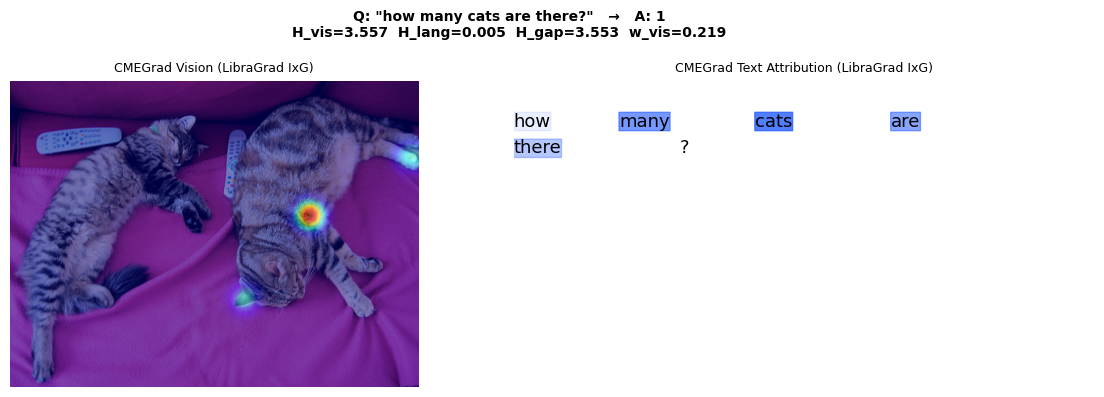

  ✓ saved  H_gap=3.553
Processing: what color cloth is the man wearing?


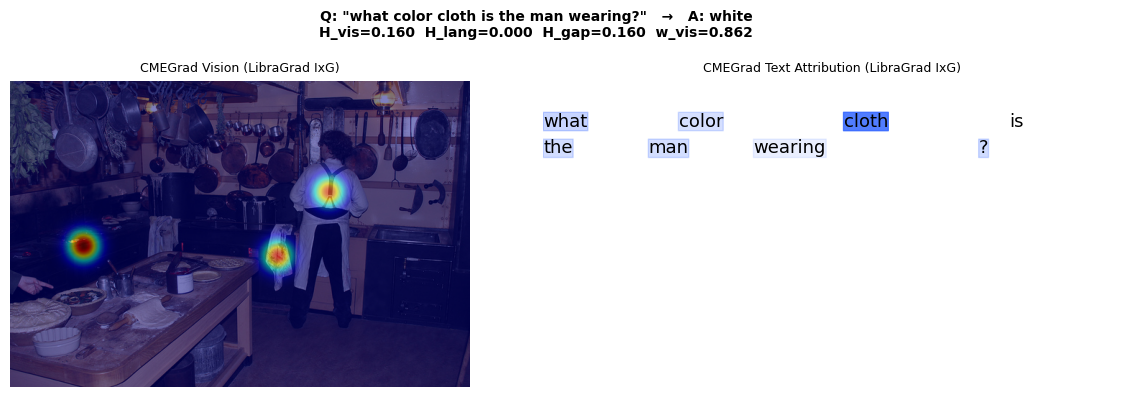

  ✓ saved  H_gap=0.160
Processing: what is on the table?


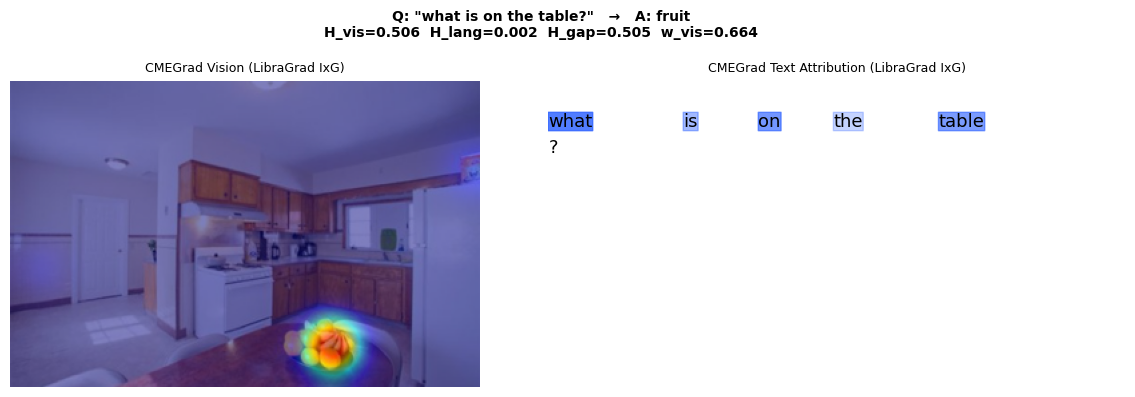

  ✓ saved  H_gap=0.505
✓ Cell 7 complete


In [33]:
# ── Cell 7: Visualization (reference style) ───────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "grad-cam"], check=True)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.text import Text
from pytorch_grad_cam.utils.image import show_cam_on_image
from scipy.ndimage import gaussian_filter

# ── Text visualization helpers (from reference) ───────────────────────────────

class TextWithBGColor(Text):
    def __init__(self, x, y, text, bgcolor, *args, **kwargs):
        super().__init__(x, y, text, *args, **kwargs)
        self.bgcolor = bgcolor

    def draw(self, renderer, *args, **kwargs):
        bbox = dict(facecolor=self.bgcolor, edgecolor=self.bgcolor,
                    boxstyle='round,pad=0.01', alpha=self.bgcolor[3])
        self.set_bbox(bbox)
        super().draw(renderer, *args, **kwargs)

def plot_text_with_colors(ax, tokens, rgba_colors,
                           max_width=100, max_height=4, fontsize=12):
    x, y        = 0, max_height
    space_width = fontsize * 0.2
    for i, (token, color) in enumerate(zip(tokens, rgba_colors)):
        text = TextWithBGColor(x, y * 0.7, token, color, fontsize=fontsize)
        ax.add_artist(text)
        token_width = fontsize * 0.4 * len(token)
        if i + 1 < len(tokens):
            next_w = fontsize * 0.4 * len(tokens[i + 1]) + space_width
            if x + token_width + next_w >= max_width:
                x  = 0
                y -= 1
            else:
                x += token_width + space_width
        else:
            x += token_width

def generate_shades_with_alpha(scores, min_alpha=0.0, max_alpha=0.85):
    mn, mx = min(scores), max(scores)
    norm   = [(s - mn) / (mx - mn + 1e-10) for s in scores]
    return [(0.2, 0.4, 1.0, min_alpha + s * (max_alpha - min_alpha))
            for s in norm]

# ── Box attribution → pixel heatmap (center-point approach) ───────────────────

def boxes_to_heatmap(img_pil, boxes, attr, sigma=10, alpha=0.55, top_k=3):
    W, H     = img_pil.size
    canvas   = np.zeros((H, W), dtype=np.float32)
    scores   = attr.float().numpy()
    scores   = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)
    boxes_np = boxes.numpy()
    top_idx  = np.argsort(scores)[::-1][:top_k]

    for i in top_idx:
        cx = int((boxes_np[i, 0] + boxes_np[i, 2]) / 2 * W)
        cy = int((boxes_np[i, 1] + boxes_np[i, 3]) / 2 * H)
        cx = max(0, min(W - 1, cx))
        cy = max(0, min(H - 1, cy))
        canvas[cy, cx] += scores[i] ** 3.5
        

    canvas = gaussian_filter(canvas, sigma=sigma)
    mn, mx = canvas.min(), canvas.max()
    return (canvas - mn) / (mx - mn + 1e-10)

# ── Main visualization ────────────────────────────────────────────────────────

MAX_WIDTH  = 100
MAX_HEIGHT = 4

for ex in EXAMPLES:
    print(f"Processing: {ex['q']}")
    rt, ri, info = cmegrad.generate(ex["q"], ex["image_id"])

    vis_raw  = info["vis_attr_raw"].float()
    boxes    = info["boxes"]
    tokens   = [t for t in info["tokens"]
                if t not in ["[PAD]", "[CLS]", "[SEP]"]]
    text_scores = rt.float().numpy()

    # Vision heatmap
    img_np   = np.array(ex["img_pil"]).astype(np.float32) / 255.0
    vmap     = boxes_to_heatmap(ex["img_pil"], boxes, vis_raw, sigma=15)
    vis_overlay = show_cam_on_image(img_np, vmap, use_rgb=True)

    # Text colors (blue-alpha from reference)
    tmap         = rt.float().tolist()
    # Prepend/append dummy for [CLS]/[SEP] as reference expects full seq
    tmap_full    = [0.0] + tmap[:len(tokens)] + [0.0]
    rgba_colors  = generate_shades_with_alpha(tmap_full[1:-1])

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(
        f'Q: "{ex["q"]}"   →   A: {info["pred_answer"]}\n'
        f'H_vis={info["H_vis"]:.3f}  H_lang={info["H_lang"]:.3f}'
        f'  H_gap={info["H_gap"]:.3f}  w_vis={info["w_vis"]:.3f}',
        fontsize=10, fontweight="bold"
    )

    axs[0].imshow(vis_overlay)
    axs[0].set_title("CMEGrad Vision (LibraGrad IxG)", fontsize=9)
    axs[0].axis("off")

    plot_text_with_colors(
        axs[1], tokens, rgba_colors,
        max_width=MAX_WIDTH, max_height=MAX_HEIGHT, fontsize=13
    )
    axs[1].set_xlim(0, MAX_WIDTH)
    axs[1].set_ylim(-MAX_HEIGHT, MAX_HEIGHT)
    axs[1].set_title("CMEGrad Text Attribution (LibraGrad IxG)", fontsize=9)
    axs[1].axis("off")

    plt.tight_layout()
    img_id    = str(ex["image_id"]).zfill(12)
    save_path = os.path.join(HEATMAPS_DIR, f"cmeg_{img_id}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"  ✓ saved  H_gap={info['H_gap']:.3f}")
    plt.close()

print("✓ Cell 7 complete")

In [34]:
# ── Cell 8: 500-sample CMAES Evaluation ──────────────────────────────────────
import random
import json
from tqdm import tqdm

random.seed(42)
EVAL_N = 500

# ── Sample 500 QA pairs from val2017 ─────────────────────────────────────────
all_qa    = [q for q in questions if q["answer"] in id2label.values()]
eval_qa   = random.sample(all_qa, min(EVAL_N, len(all_qa)))
print(f"Evaluation set: {len(eval_qa)} QA pairs")

# ── Metrics storage ───────────────────────────────────────────────────────────
results = {
    "cmeg":     {"H_vis": [], "H_lang": [], "H_gap": [], "w_vis": []},
    "baseline": {"H_vis": [], "H_lang": [], "H_gap": []},
}
errors  = 0

# ── Baseline: IxG text only (no cross-modal refinement) ──────────────────────
def baseline_cmaes(question, image_id):
    """LibraGrad IxG text + uniform vision (no bridge, no refinement)."""
    feats, boxes = load_image_features_fast(image_id, feat_index)
    enc = tokenizer(
        question, padding="max_length", max_length=20,
        truncation=True, return_tensors="pt"
    ).to(device)
    feats = feats.to(device)
    boxes = boxes.to(device)

    text_attr, _ = cmegrad._text_attr(enc, feats, boxes)
    vis_attr      = torch.ones(36) / 36    # uniform vision

    _, H_vis  = cmegrad._ew(vis_attr)
    _, H_lang = cmegrad._ew(text_attr)
    H_gap     = abs(H_vis - H_lang)
    return H_vis, H_lang, H_gap

# ── Evaluation loop ───────────────────────────────────────────────────────────
print(f"\nRunning evaluation on {len(eval_qa)} samples...")
for i, qa in enumerate(tqdm(eval_qa, desc="CMEGrad eval")):
    try:
        # CMEGrad
        _, _, info = cmegrad.generate(qa["question"], qa["image_id"])
        results["cmeg"]["H_vis"].append(info["H_vis"])
        results["cmeg"]["H_lang"].append(info["H_lang"])
        results["cmeg"]["H_gap"].append(info["H_gap"])
        results["cmeg"]["w_vis"].append(info["w_vis"])

        # Baseline
        H_vis_b, H_lang_b, H_gap_b = baseline_cmaes(
            qa["question"], qa["image_id"])
        results["baseline"]["H_vis"].append(H_vis_b)
        results["baseline"]["H_lang"].append(H_lang_b)
        results["baseline"]["H_gap"].append(H_gap_b)

    except Exception as e:
        errors += 1
        continue

print(f"\n  Completed: {len(results['cmeg']['H_vis'])}/{len(eval_qa)}")
print(f"  Errors:    {errors}")

# ── Report ────────────────────────────────────────────────────────────────────
import numpy as np

def report(name, d):
    h_vis  = np.array(d["H_vis"])
    h_lang = np.array(d["H_lang"])
    h_gap  = np.array(d["H_gap"])
    print(f"\n  {name}")
    print(f"    H_vis:  {h_vis.mean():.4f} ± {h_vis.std():.4f}")
    print(f"    H_lang: {h_lang.mean():.4f} ± {h_lang.std():.4f}")
    print(f"    H_gap:  {h_gap.mean():.4f} ± {h_gap.std():.4f}")
    return h_vis.mean(), h_lang.mean(), h_gap.mean()

print("\n" + "="*50)
print("CMAES Evaluation Results (500 samples)")
print("="*50)
cmeg_vis, cmeg_lang, cmeg_gap = report("CMEGrad", results["cmeg"])
base_vis, base_lang, base_gap = report("Baseline (IxG only)", results["baseline"])

print(f"\n  H_gap improvement: "
      f"{((cmeg_gap - base_gap) / base_gap * 100):+.1f}%")
print(f"  Mean w_vis: "
      f"{np.mean(results['cmeg']['w_vis']):.4f}")

# ── Save results ──────────────────────────────────────────────────────────────
save = {
    "n_samples":    len(results["cmeg"]["H_vis"]),
    "cmeg":         {k: float(np.mean(v))
                     for k, v in results["cmeg"].items()},
    "baseline":     {k: float(np.mean(v))
                     for k, v in results["baseline"].items()},
    "cmeg_std":     {k: float(np.std(v))
                     for k, v in results["cmeg"].items()},
    "baseline_std": {k: float(np.std(v))
                     for k, v in results["baseline"].items()},
}
with open(os.path.join(RESULTS_DIR, "cmaes_500.json"), "w") as f:
    json.dump(save, f, indent=2)
print(f"\n  Results saved to {RESULTS_DIR}/cmaes_500.json")
print("✓ Cell 8 complete")

Evaluation set: 500 QA pairs

Running evaluation on 500 samples...


CMEGrad eval: 100%|███████████████████████████| 500/500 [03:14<00:00,  2.57it/s]


  Completed: 500/500
  Errors:    0

CMAES Evaluation Results (500 samples)

  CMEGrad
    H_vis:  2.4600 ± 1.2079
    H_lang: 0.1016 ± 0.2788
    H_gap:  2.3779 ± 1.1987

  Baseline (IxG only)
    H_vis:  3.5835 ± 0.0000
    H_lang: 0.1016 ± 0.2788
    H_gap:  3.4820 ± 0.2788

  H_gap improvement: -31.7%
  Mean w_vis: 0.3639

  Results saved to /media/crk/vol3/rt/cmegard_lxmert/results/cmaes_500.json
✓ Cell 8 complete
